##### Cellule 1 : Setup & sélection des familles

In [2]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import warnings, joblib, os
warnings.filterwarnings('ignore')

from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from sklearn.metrics import mean_absolute_error
from sklearn.linear_model import Ridge

import sys
sys.path.append('..')
from src.data_loader import load_data, filter_series
from src.feature_engineering import (add_calendar_features, add_lag_features,
                                      add_rolling_features, add_promo_features,
                                      add_interaction_features)

plt.style.use('seaborn-v0_8-whitegrid')

df = load_data('../data/')

# Top 10 familles par volume de ventes — magasin 1
top_families = (df[df['store_nbr']==1]
                .groupby('family')['sales']
                .sum()
                .sort_values(ascending=False)
                .head(10)
                .index.tolist())

print("Familles sélectionnées :")
for i, f in enumerate(top_families, 1):
    vol = df[(df['store_nbr']==1) & (df['family']==f)]['sales'].sum()
    print(f"  {i:>2}. {f:<25} — {vol:>12,.0f} unités vendues")

Familles sélectionnées :
   1. GROCERY I                 —    3,813,622 unités vendues
   2. BEVERAGES                 —    2,722,710 unités vendues
   3. PRODUCE                   —    2,489,110 unités vendues
   4. CLEANING                  —    1,096,956 unités vendues
   5. DAIRY                     —    1,073,095 unités vendues
   6. BREAD/BAKERY              —      579,547 unités vendues
   7. MEATS                     —      535,800 unités vendues
   8. POULTRY                   —      486,428 unités vendues
   9. EGGS                      —      240,410 unités vendues
  10. FROZEN FOODS              —      224,114 unités vendues


##### Cellule 2 : Pipeline de features réutilisable

In [3]:

def add_advanced_features(d):
    d = d.copy()
    t = (d.index - d.index.min()).days
    d['dow_sin']  = np.sin(2 * np.pi * d.index.dayofweek / 7)
    d['dow_cos']  = np.cos(2 * np.pi * d.index.dayofweek / 7)
    d['month_sin'] = np.sin(2 * np.pi * d.index.month / 12)
    d['month_cos'] = np.cos(2 * np.pi * d.index.month / 12)
    d['trend']    = t / 365.25
    for k in [1, 2, 3]:
        d[f'fourier_sin_{k}'] = np.sin(2 * np.pi * k * t / 365.25)
        d[f'fourier_cos_{k}'] = np.cos(2 * np.pi * k * t / 365.25)
    d['rolling_mean_90d'] = d['sales'].shift(1).rolling(90, min_periods=30).mean()
    d['rolling_mean_60d'] = d['sales'].shift(1).rolling(60, min_periods=20).mean()
    d['ratio_7_28'] = (d['rolling_mean_7d'] /
                       d['rolling_mean_28d'].replace(0, np.nan)).fillna(1)
    d['spike_flag'] = (d['rolling_max_7d'] > d['rolling_mean_28d'] * 1.5).astype('int8')
    return d.dropna()


def build_full_features(df, store_nbr, family):
    d = filter_series(df, store_nbr, family)
    d = add_calendar_features(d)
    d = add_lag_features(d)
    d = add_rolling_features(d)
    d = add_promo_features(d)
    d = add_interaction_features(d)
    d = add_advanced_features(d)
    return d


def train_ensemble(d):
    FEAT  = [c for c in d.columns if c != 'sales']
    split = int(len(d) * 0.8)
    X_tr, X_te = d[FEAT].iloc[:split], d[FEAT].iloc[split:]
    y_tr, y_te = d['sales'].iloc[:split],  d['sales'].iloc[split:]

    if len(X_tr) < 100:
        return None

    # XGBoost
    m_xgb = XGBRegressor(n_estimators=500, learning_rate=0.05,
                          max_depth=6, subsample=0.8,
                          colsample_bytree=0.8, random_state=42)
    m_xgb.fit(X_tr, y_tr)

    # LightGBM
    m_lgbm = LGBMRegressor(n_estimators=500, learning_rate=0.05,
                            max_depth=6, num_leaves=63,
                            subsample=0.8, random_state=42, verbosity=-1)
    m_lgbm.fit(X_tr, y_tr)

    # Ensemble pondéré
    p_xgb  = m_xgb.predict(X_te)
    p_lgbm = m_lgbm.predict(X_te)
    mae_x  = mean_absolute_error(y_te, p_xgb)
    mae_l  = mean_absolute_error(y_te, p_lgbm)
    w      = np.array([1/mae_x, 1/mae_l])
    w      = w / w.sum()
    p_ens  = w[0]*p_xgb + w[1]*p_lgbm

    mae_ens = mean_absolute_error(y_te, p_ens)
    mae_err_rel = mae_ens / y_te.mean() * 100 if y_te.mean() > 0 else np.nan

    return {
        'mae':          mae_ens,
        'mae_xgb':      mae_x,
        'mae_lgbm':     mae_l,
        'mae_rel':      mae_err_rel,
        'y_te':         y_te,
        'pred':         p_ens,
        'n_train':      len(X_tr),
        'n_test':       len(X_te),
        'feat_imp':     pd.Series(m_xgb.feature_importances_, index=FEAT),
        'ventes_moy':   y_te.mean(),
        'weights':      w,
    }

print("Fonctions définies ✓")

Fonctions définies ✓


##### Cellule 3 : Entraînement sur toutes les familles

In [4]:

results = {}
print(f"{'Famille':<25} {'N train':>8} {'MAE':>8} {'MAE rel':>9} {'Statut'}")
print("─" * 65)

for family in top_families:
    try:
        d = build_full_features(df, store_nbr=1, family=family)
        r = train_ensemble(d)
        if r is None:
            print(f"{family:<25} {'—':>8} {'—':>8} {'—':>9} ⚠ Trop peu de données")
            continue
        results[family] = r
        status = '✅' if r['mae_rel'] < 20 else '⚡' if r['mae_rel'] < 40 else '⚠'
        print(f"{family:<25} {r['n_train']:>8} {r['mae']:>8.1f} {r['mae_rel']:>8.1f}%  {status}")
    except Exception as e:
        print(f"{family:<25} Erreur : {e}")

print(f"\n{len(results)} familles entraînées avec succès")

Famille                    N train      MAE   MAE rel Statut
─────────────────────────────────────────────────────────────────
GROCERY I                     1347    273.9     10.4%  ✅
BEVERAGES                     1347    273.6     12.6%  ✅
PRODUCE                       1347    203.2      8.3%  ✅
CLEANING                      1347     67.9     10.3%  ✅
DAIRY                         1347     63.1      8.7%  ✅
BREAD/BAKERY                  1347     42.5     11.5%  ✅
MEATS                         1347     58.6     18.9%  ✅
POULTRY                       1347     38.5     12.4%  ✅
EGGS                          1347     13.8     10.1%  ✅
FROZEN FOODS                  1347     37.6     27.2%  ⚡

10 familles entraînées avec succès


##### Cellule 4 : Visualisation comparative

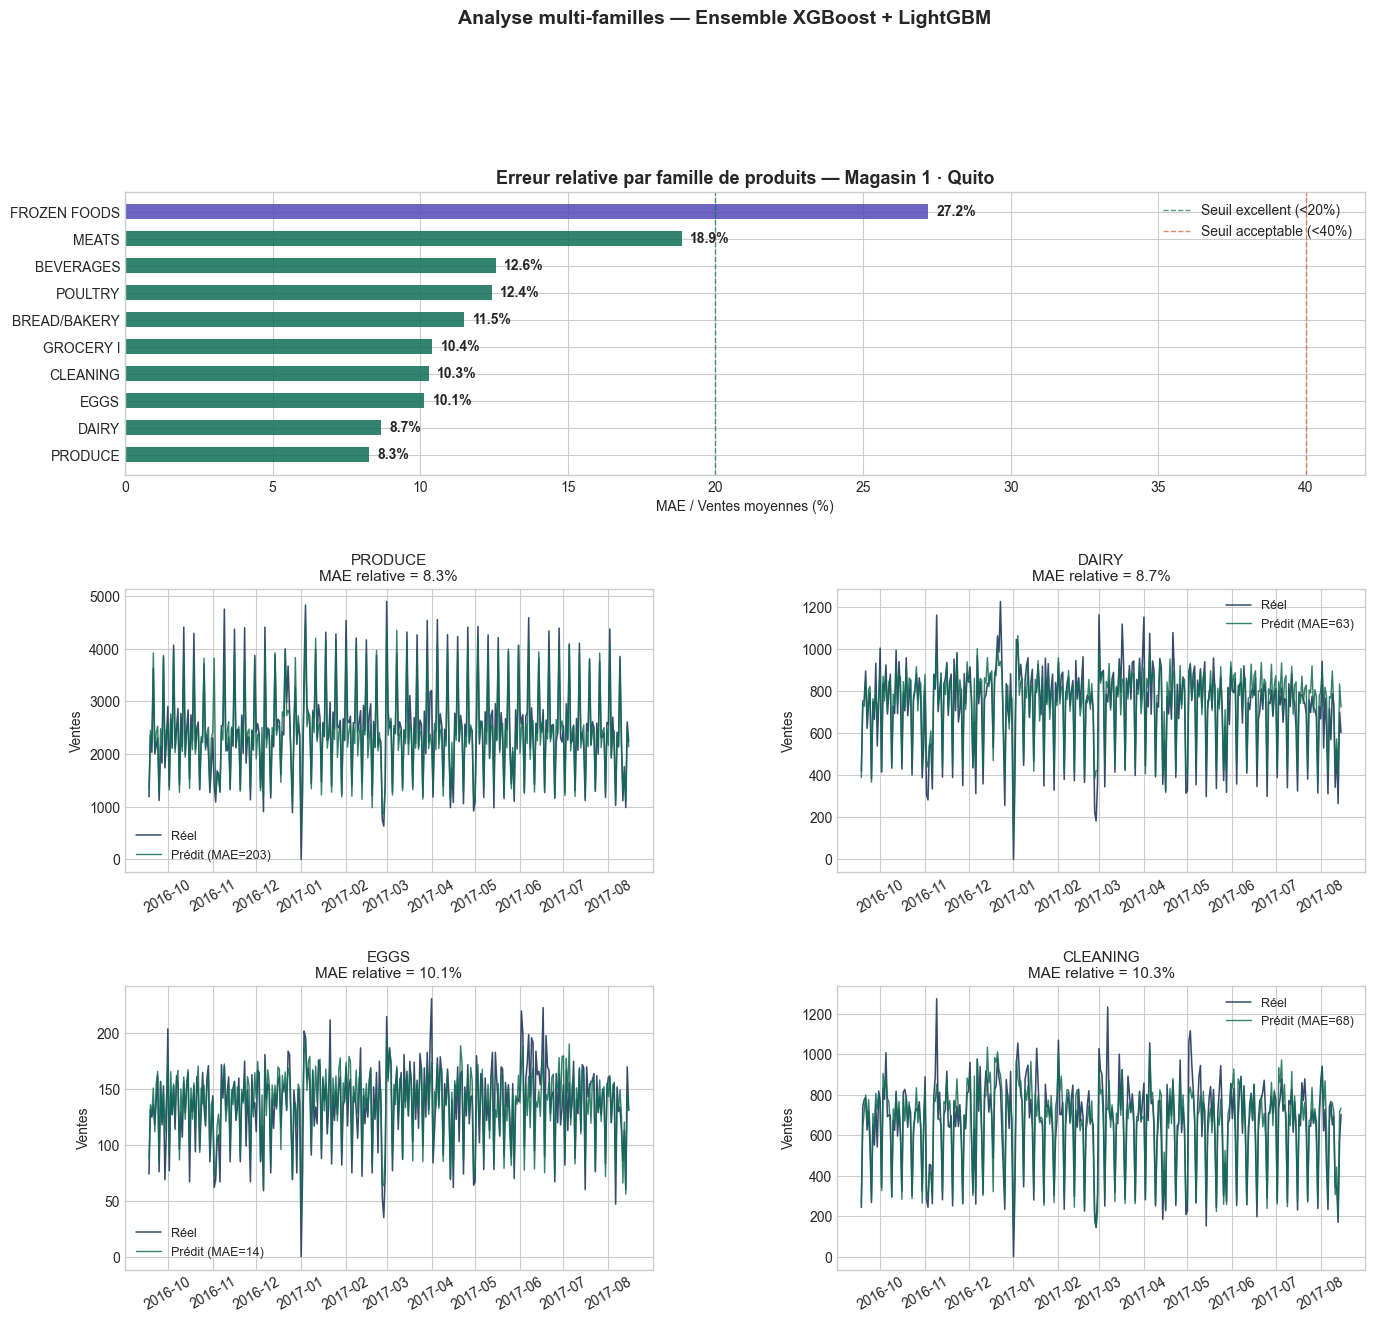

In [5]:

families_ok = list(results.keys())
maes        = [results[f]['mae']     for f in families_ok]
maes_rel    = [results[f]['mae_rel'] for f in families_ok]
ventes_moy  = [results[f]['ventes_moy'] for f in families_ok]

# Trier par MAE relative
order = np.argsort(maes_rel)
fam_sorted  = [families_ok[i] for i in order]
mae_sorted  = [maes_rel[i]    for i in order]

fig = plt.figure(figsize=(16, 14))
gs  = fig.add_gridspec(3, 2, hspace=0.4, wspace=0.35)

# ─── Graphique 1 : MAE relative par famille ──────────────────
ax1 = fig.add_subplot(gs[0, :])
colors_sorted = ['#0F6E56' if m < 20 else '#534AB7' if m < 40 else '#D85A30'
                 for m in mae_sorted]
bars = ax1.barh(fam_sorted, mae_sorted, color=colors_sorted, alpha=0.85, height=0.55)
ax1.bar_label(bars, fmt='%.1f%%', padding=6, fontsize=10, fontweight='bold')
ax1.axvline(20, color='#0F6E56', linestyle='--', linewidth=1, alpha=0.7, label='Seuil excellent (<20%)')
ax1.axvline(40, color='#D85A30', linestyle='--', linewidth=1, alpha=0.7, label='Seuil acceptable (<40%)')
ax1.set_xlabel('MAE / Ventes moyennes (%)')
ax1.set_title('Erreur relative par famille de produits — Magasin 1 · Quito',
              fontsize=13, fontweight='bold')
ax1.legend(fontsize=10)

# ─── Graphique 2 : Prédictions vs Réel — Top 4 familles ─────
top4 = fam_sorted[:4]
for i, fam in enumerate(top4):
    ax = fig.add_subplot(gs[1 + i//2, i%2])
    r  = results[fam]
    ax.plot(r['y_te'].index, r['y_te'].values,
            label='Réel', color='#1E3A5F', linewidth=1.1, alpha=0.9)
    ax.plot(r['y_te'].index, r['pred'],
            label=f"Prédit (MAE={r['mae']:.0f})",
            color='#0F6E56', linewidth=1, alpha=0.85)
    ax.fill_between(r['y_te'].index, r['y_te'].values, r['pred'],
                    alpha=0.08, color='#D85A30')
    ax.set_title(f"{fam}\nMAE relative = {r['mae_rel']:.1f}%", fontsize=11)
    ax.set_ylabel('Ventes')
    ax.legend(fontsize=9)
    ax.tick_params(axis='x', rotation=30)

plt.suptitle('Analyse multi-familles — Ensemble XGBoost + LightGBM',
             fontsize=14, fontweight='bold', y=1.01)
plt.savefig('multi_family_results.png', dpi=150, bbox_inches='tight')
plt.show()

##### Cellule 5 : Features les plus importantes par famille

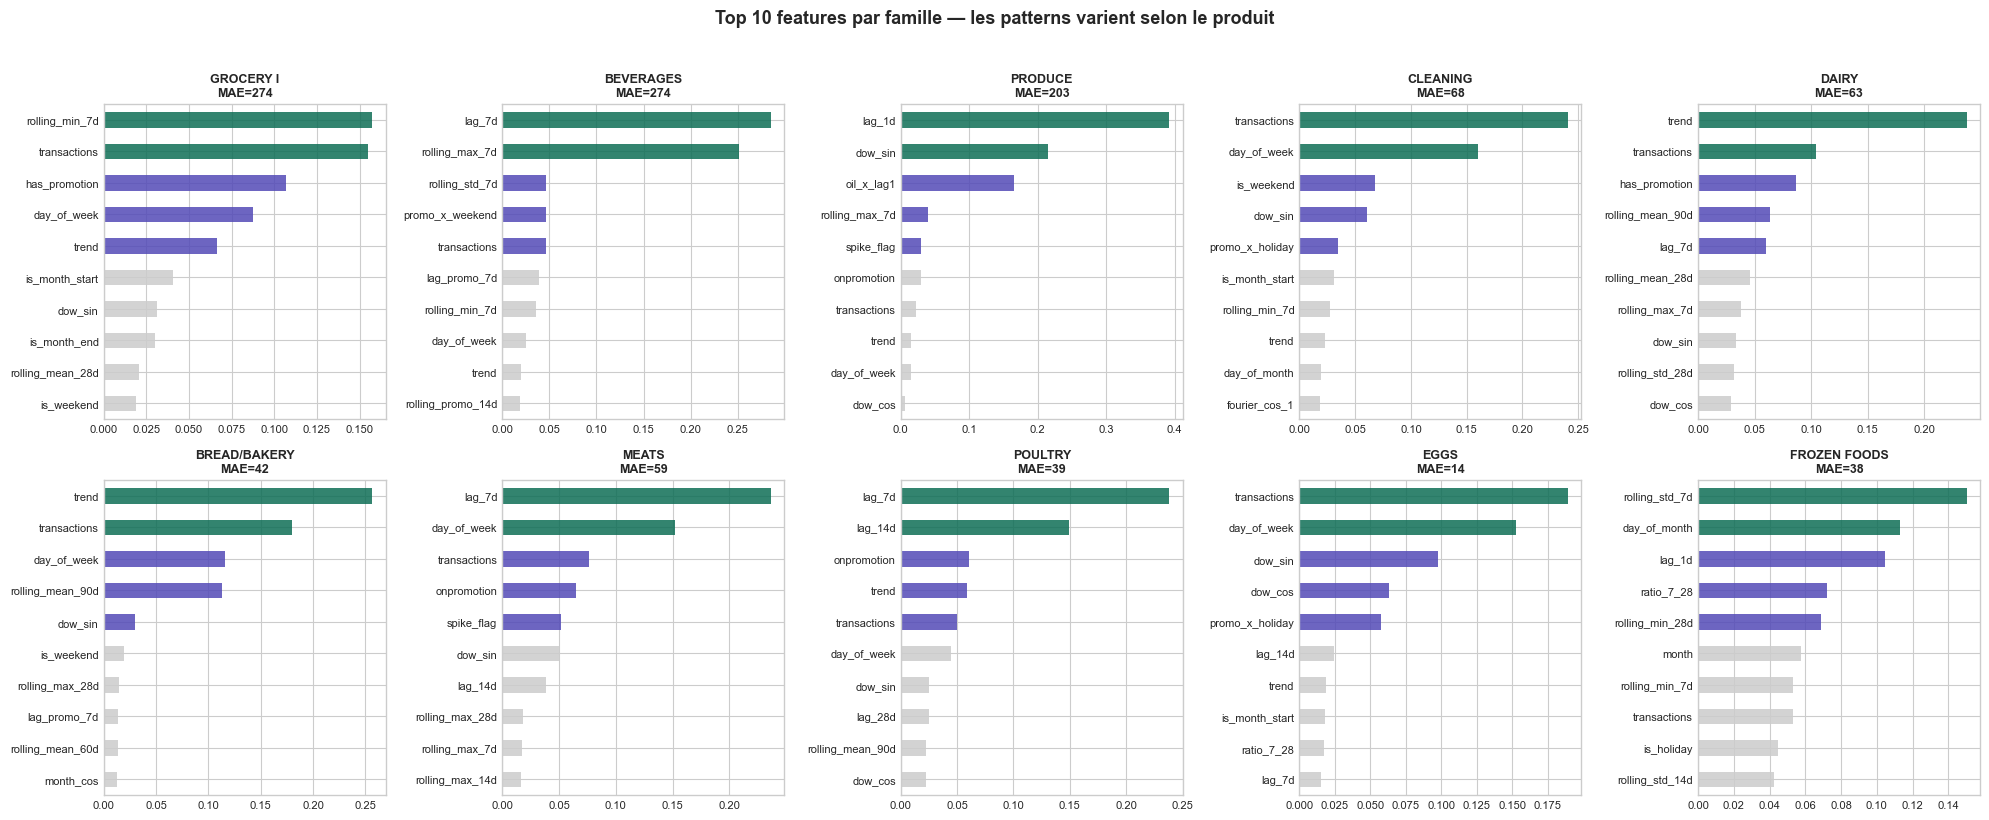

In [6]:

fig, axes = plt.subplots(2, 5, figsize=(20, 8))
axes = axes.flatten()

for i, fam in enumerate(families_ok[:10]):
    top10 = results[fam]['feat_imp'].nlargest(10).sort_values()
    colors_fi = ['#0F6E56' if j >= 8 else '#534AB7' if j >= 5 else '#CCCCCC'
                 for j in range(len(top10))]
    top10.plot(kind='barh', ax=axes[i], color=colors_fi, alpha=0.85)
    axes[i].set_title(f"{fam[:20]}\nMAE={results[fam]['mae']:.0f}",
                      fontsize=9, fontweight='bold')
    axes[i].set_xlabel('')
    axes[i].tick_params(labelsize=8)
    axes[i].set_yticklabels([l[:18] for l in top10.index], fontsize=8)

plt.suptitle('Top 10 features par famille — les patterns varient selon le produit',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('multi_family_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

##### Cellule 6 : Tableau de synthèse décisionnel

In [ ]:

print("\n" + "═"*75)
print("SYNTHÈSE DÉCISIONNELLE — PRÉVISIBILITÉ DES VENTES PAR FAMILLE")
print("═"*75)
print(f"\n{'Famille':<25} {'MAE':>7} {'Erreur rel':>11} {'Prévisibilité':>15} {'Action recommandée'}")
print("─"*75)

for fam in fam_sorted:
    r   = results[fam]
    rel = r['mae_rel']
    if rel < 15:
        level = '🟢 Excellente'
        action = 'Automatiser la planification stock'
    elif rel < 25:
        level = '🟡 Bonne'
        action = 'Utiliser le modèle avec validation humaine'
    elif rel < 40:
        level = '🟠 Moyenne'
        action = 'Enrichir avec données externes'
    else:
        level = '🔴 Difficile'
        action = 'Revoir la stratégie de features'
    print(f"{fam:<25} {r['mae']:>7.1f} {rel:>10.1f}%  {level:>15}  {action}")

print("─"*75)
avg_mae_rel = np.mean([results[f]['mae_rel'] for f in results])
print(f"\nErreur relative moyenne toutes familles : {avg_mae_rel:.1f}%")

# Sauvegarder tous les résultats
os.makedirs('../models', exist_ok=True)
joblib.dump(results, '../models/multi_family_results.pkl')
print("Résultats sauvegardés → models/multi_family_results.pkl ✓")


═══════════════════════════════════════════════════════════════════════════
SYNTHÈSE DÉCISIONNELLE — PRÉVISIBILITÉ DES VENTES PAR FAMILLE
═══════════════════════════════════════════════════════════════════════════

Famille                       MAE  Erreur rel   Prévisibilité Action recommandée
───────────────────────────────────────────────────────────────────────────
PRODUCE                     203.2        8.3%     🟢 Excellente  Automatiser la planification stock
DAIRY                        63.1        8.7%     🟢 Excellente  Automatiser la planification stock
EGGS                         13.8       10.1%     🟢 Excellente  Automatiser la planification stock
CLEANING                     67.9       10.3%     🟢 Excellente  Automatiser la planification stock
GROCERY I                   273.9       10.4%     🟢 Excellente  Automatiser la planification stock
BREAD/BAKERY                 42.5       11.5%     🟢 Excellente  Automatiser la planification stock
POULTRY                      38.5